In [91]:
import geopandas as gpd
import pathlib
import contextily
import matplotlib.pyplot as plt
import matplotlib_scalebar.scalebar as sb
import pandas as pd
from shapely.geometry import Polygon, Point, LineString
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import osmnx as ox
from matplotlib.lines import Line2D

In [2]:
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / 'data'
MAP_DIRECTORY = NOTEBOOK_PATH / "maps"
MAP_DIRECTORY.mkdir(exist_ok=True)

In [ ]:
data = gpd.read_file(DATA_DIRECTORY / "NCS_2020_Helsinki")
data.head()

,geoAnswerI,buttonname,Respondent,geometry
0,2374262,Places for leisure time physical activity,1625,POINT (378130.276 6673970.108)
1,2374264,Places for leisure time physical activity,1625,POINT (377714.091 6674052.472)
2,2374322,Places where I enjoy nature or being outdoors,1625,POINT (378129.46 6673515.444)
3,2374325,Places where I enjoy urban life,1625,POINT (378246.203 6672955.656)
4,2374328,Places where I enjoy urban life,1625,POINT (374395.188 6671353.576)


<Axes: >

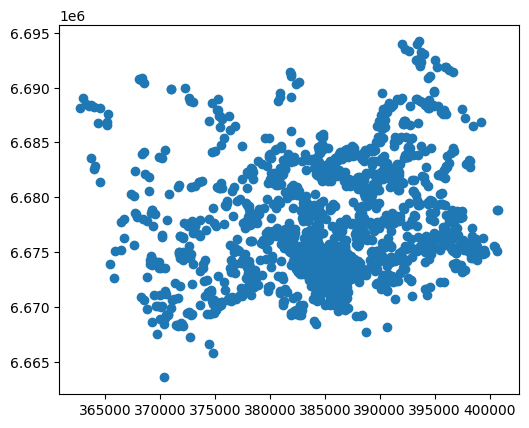

In [4]:
data.plot()

In [8]:
data["buttonname"].unique()
data["buttonname"].value_counts()

buttonname
Places for leisure time physical activity           569
Places where I enjoy nature or being outdoors       326
Places where I spend time with family or friends    214
Places where I enjoy urban life                     180
Places that help me relax                           162
Places that help me escape stress                   143
Places where I can run into good people             103
Name: count, dtype: int64

In [9]:
espoo_data = gpd.read_file(DATA_DIRECTORY / "NORDGREEN_Espoo")
espoo_data.head()

,N_PROB,P_PROB,geometry
0,0.41,0.65,"POLYGON ((375079.283 6660167.392, 375079.283 6..."
1,0.40,0.66,"POLYGON ((375129.283 6660167.392, 375129.283 6..."
2,0.40,0.66,"POLYGON ((375179.283 6660167.392, 375179.283 6..."
3,0.41,0.65,"POLYGON ((375229.283 6660167.392, 375229.283 6..."
4,0.41,0.64,"POLYGON ((374979.283 6660217.392, 374979.283 6..."


<Axes: >

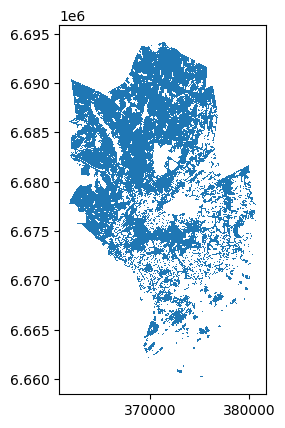

In [10]:
espoo_data.plot()

<Axes: >

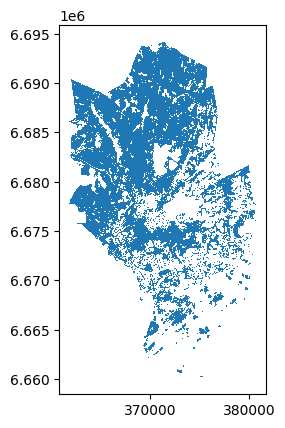

In [11]:
espoo_data[espoo_data["P_PROB"] > espoo_data["N_PROB"]].plot()

<Axes: >

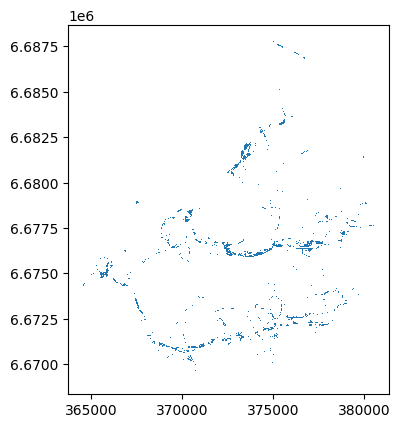

In [12]:
espoo_data[espoo_data["P_PROB"] < espoo_data["N_PROB"]].plot()

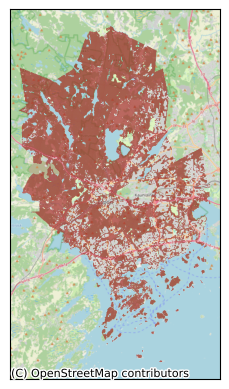

In [14]:
import contextily
points_to_vis = espoo_data.to_crs("EPSG:3857")
ax = points_to_vis.plot(markersize=3, color='brown')
# Remove ticks and axis labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
contextily.add_basemap(ax, source=contextily.providers.OpenStreetMap.Mapnik)

In [18]:
pmin, pmax, nmin, nmax = espoo_data.P_PROB.min(), espoo_data.P_PROB.max(), espoo_data.N_PROB.min(),  espoo_data.N_PROB.max()
print(pmin, pmax, nmin, nmax)

0.51 0.78 0.36 0.64


In [21]:
def visualize(data, col):
    # Transform to Web Mercator
    points_to_vis = data.to_crs("EPSG:3857")

    ax = points_to_vis.plot(markersize=7, column=col, cmap="plasma", legend=True, alpha = 0.8, edgecolor='none')

    # Adding a basemap
    contextily.add_basemap(ax, source=contextily.providers.CartoDB.Positron, alpha=0.8)

    # Remove ticks and axis labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    # set this to off if you want to remove the frame
    ax.axis('on')
    # Adjust figure size to accommodate the legend, if necessary
    fig = ax.figure
    fig.set_size_inches(8, 6)
    fig.tight_layout()

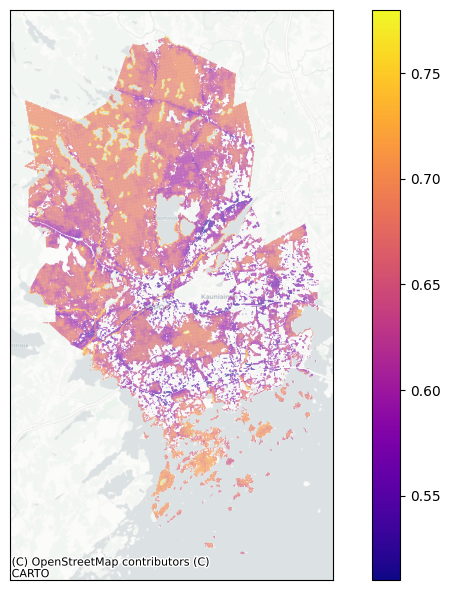

In [22]:
visualize(espoo_data, 'P_PROB')

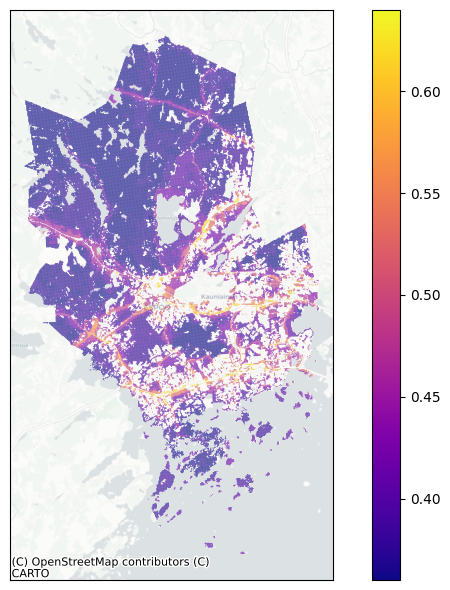

In [23]:
visualize(espoo_data, 'N_PROB')

In [ ]:
espoo_data['S_PROB'] = espoo_data['N_PROB'] + espoo_data['P_PROB']
print(espoo_data['S_PROB'].min(), espoo_data['S_PROB'].max())

0.99 1.26


In [25]:
espoo_data['A_PROB'] = espoo_data['P_PROB'] - espoo_data['N_PROB']
print(espoo_data['A_PROB'].min(), espoo_data['A_PROB'].max())

-0.12 0.41000000000000003


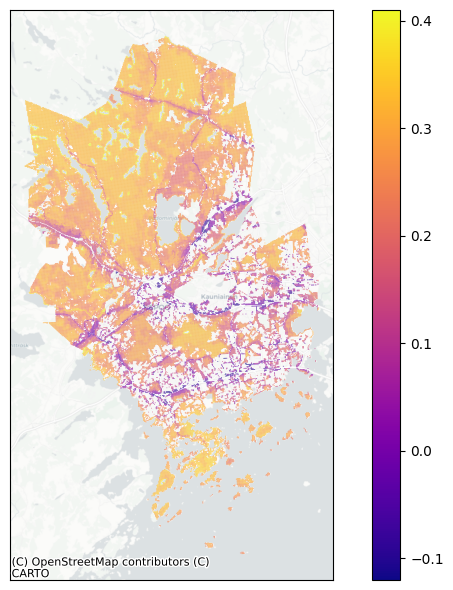

In [26]:
visualize(espoo_data, 'A_PROB')

<Axes: >

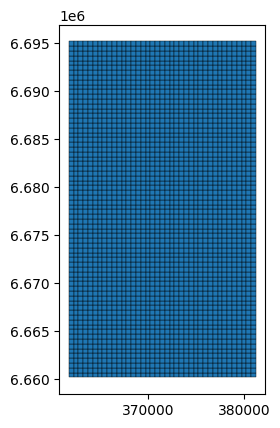

In [38]:
# Grid over Espoo
minx, miny, maxx, maxy = espoo_data.total_bounds

# Grid dimensions
grid_height = 500
grid_width = 500

# Generate the x and y coordinates for the grid
x_coords = np.arange(minx, maxx + grid_width, grid_width)
y_coords = np.arange(miny, maxy + grid_height, grid_height)

# Initialize a list to hold the grid polygons
grid_polygons = []

for x in x_coords:
    for y in y_coords:
        # Define the polygon for each cell
        polygon = Polygon([(x, y), (x+grid_width, y), (x+grid_width, y+grid_height), (x, y+grid_height)])
        grid_polygons.append(polygon)

# Create a GeoDataFrame from the grid polygons
grid = gpd.GeoDataFrame({'geometry': grid_polygons}, crs=espoo_data.crs)
grid.plot(edgecolor="black", linewidth=0.3)


In [39]:
# Perform the spatial join
joined_gdf = gpd.sjoin(grid, espoo_data, how="inner", predicate='contains')

joined_gdf.head()

,geometry,index_right,N_PROB,P_PROB,S_PROB,A_PROB
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",27904,0.37,0.74,1.11,0.37
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",27899,0.37,0.73,1.10,0.36
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",27901,0.37,0.73,1.10,0.36
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",27903,0.37,0.74,1.11,0.37
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",27902,0.37,0.73,1.10,0.36


In [40]:
# Aggregate: mean N_PROB and P_PROB per grid cell
grid_avg = (
    joined_gdf
    .groupby(joined_gdf.index)[['N_PROB', 'P_PROB']]
    .mean()
)

# Join aggregated values back to the original grid GeoDataFrame
grid_avg = grid.join(grid_avg)

# Drop grid cells with no data points
grid_avg = grid_avg.dropna(subset=['N_PROB', 'P_PROB'])

grid_avg.head()

,geometry,N_PROB,P_PROB
35,"POLYGON ((361729.283 6677667.392, 362229.283 6...",0.369714,0.667000
36,"POLYGON ((361729.283 6678167.392, 362229.283 6...",0.377179,0.620256
37,"POLYGON ((361729.283 6678667.392, 362229.283 6...",0.370000,0.630000
44,"POLYGON ((361729.283 6682167.392, 362229.283 6...",0.448000,0.639714
45,"POLYGON ((361729.283 6682667.392, 362229.283 6...",0.443077,0.600000


<Axes: >

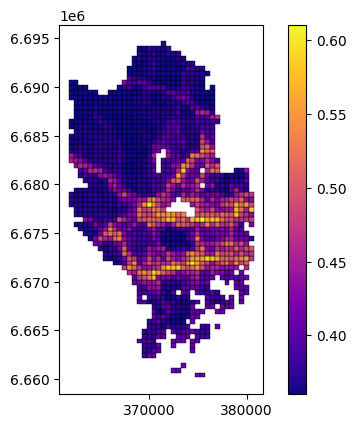

In [41]:
grid_avg.plot(column='N_PROB', cmap='plasma', legend=True, edgecolor='black', linewidth=0.3)

<Axes: >

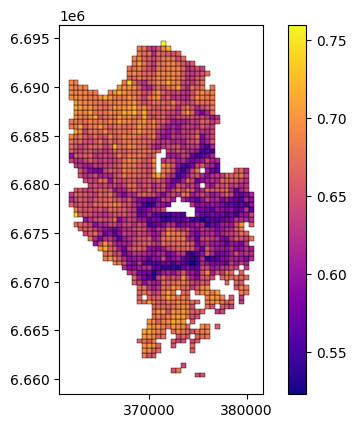

In [42]:
grid_avg.plot(column='P_PROB', cmap='plasma', legend=True, edgecolor='black', linewidth=0.3)

<Axes: >

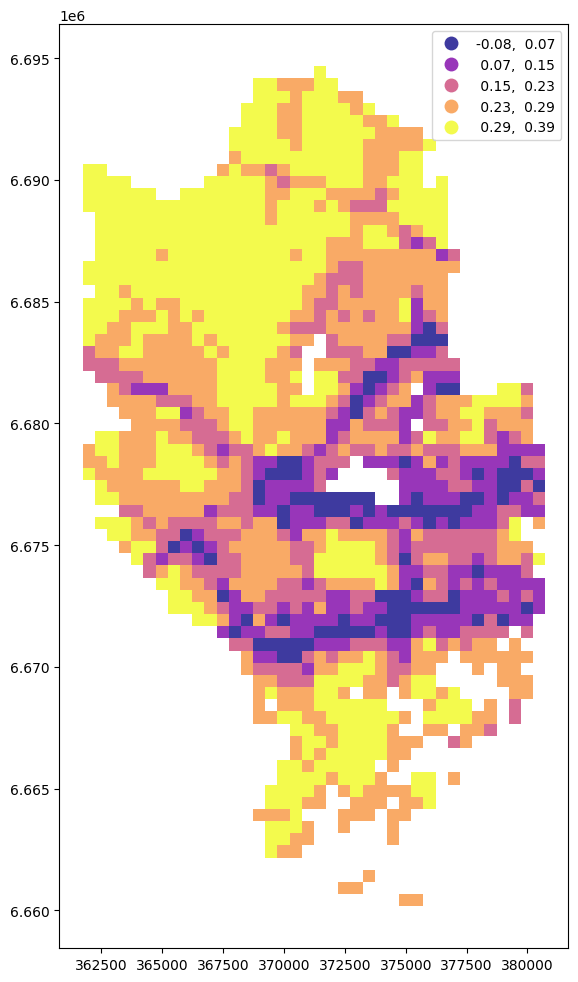

In [46]:
grid_avg['SCORE'] = grid_avg['P_PROB'] - grid_avg['N_PROB']
      
grid_avg.plot(figsize=(8, 12), column='SCORE', cmap='plasma', scheme="NaturalBreaks", linewidth=0, alpha=0.8, legend=True, edgecolor='black')

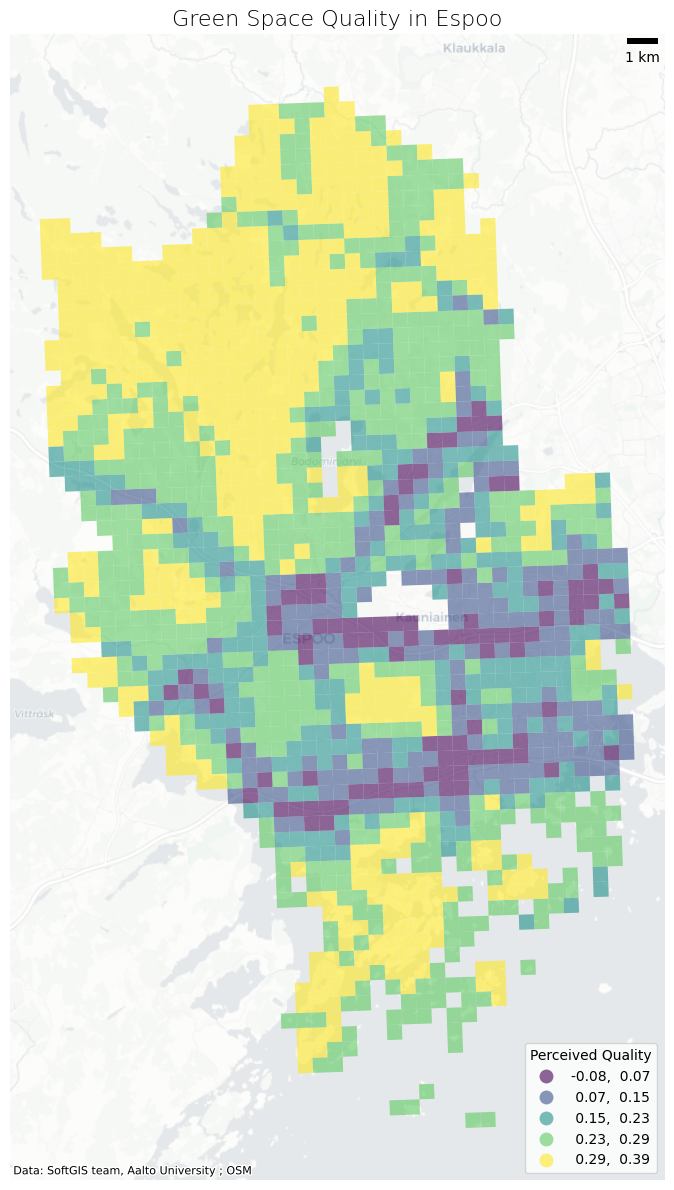

In [47]:
# Map for score of perceived green space quality across the city of Espoo

# we need CRS in web mercator to work with a basemap
final_grid = grid_avg.to_crs("EPSG:3857")

# Visualize
ax = final_grid.plot(
    figsize=(8, 12),
    
    column='SCORE',
    cmap='viridis', 
    scheme="NaturalBreaks",
    k = 5,

    linewidth=0,
    alpha=0.6,

    legend=True,
    legend_kwds={"title": "Perceived Quality", "loc": "lower right"}
)

# Remove axis
ax.set_axis_off()

plt.title('Green Space Quality in Espoo', fontdict={'fontsize': '16', 'fontweight' : '3'})
contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Positron,alpha=0.6,
    attribution=("Data: SoftGIS team, Aalto University ; OSM")
)

latitude = 60.2
scalebar = sb.ScaleBar(np.cos(np.radians(latitude)), units='m', fixed_value=1, width_fraction=0.005, fixed_units="km", location='upper right', scale_loc='bottom', box_alpha=0, color='black')
ax.add_artist(scalebar)

plt.tight_layout()
plt.show()

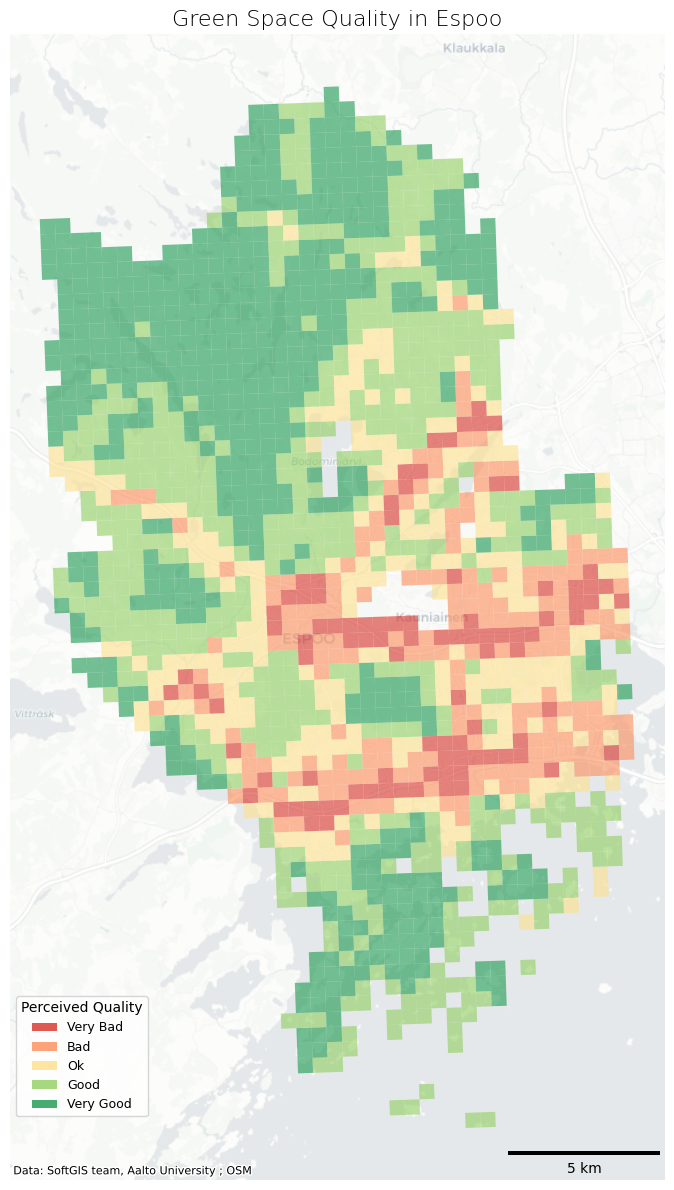

In [ ]:
# Custom colormap: red (bad) → yellow (ok) → green (good)
colors = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]
cmap_custom = LinearSegmentedColormap.from_list("green_quality", colors)

final_grid = grid_avg.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(8, 12))

final_grid.plot(
    ax=ax,
    column='SCORE',
    cmap=cmap_custom,
    scheme="NaturalBreaks",
    k=5,
    linewidth=0,
    alpha=0.6,
    legend=False,          # draw manually for custom labels
)

# --- Custom legend ---
legend_labels = ["Very Bad", "Bad", "Ok", "Good", "Very Good"]
legend_colors = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

legend_handles = [
    Patch(facecolor=color, label=label, alpha=0.8)
    for color, label in zip(legend_colors, legend_labels)
]

ax.legend(
    handles=legend_handles,
    title="Perceived Quality",
    loc="lower left",
     bbox_to_anchor = (0, 0.05),
    framealpha=0.8,
    fontsize=9,
    title_fontsize=10,
)

ax.set_axis_off()
plt.title('Green Space Quality in Espoo', fontdict={'fontsize': '16', 'fontweight': '3'})

contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Positron,
    alpha=0.6,
    attribution="Data: SoftGIS team, Aalto University ; OSM"
)

latitude = 60.2
scalebar = sb.ScaleBar(
    np.cos(np.radians(latitude)), units='m',
    fixed_value=5, width_fraction=0.003, fixed_units="km",
    location='lower right', scale_loc='bottom',
    box_alpha=0, color='black'
)
ax.add_artist(scalebar)
plt.tight_layout()
plt.show()

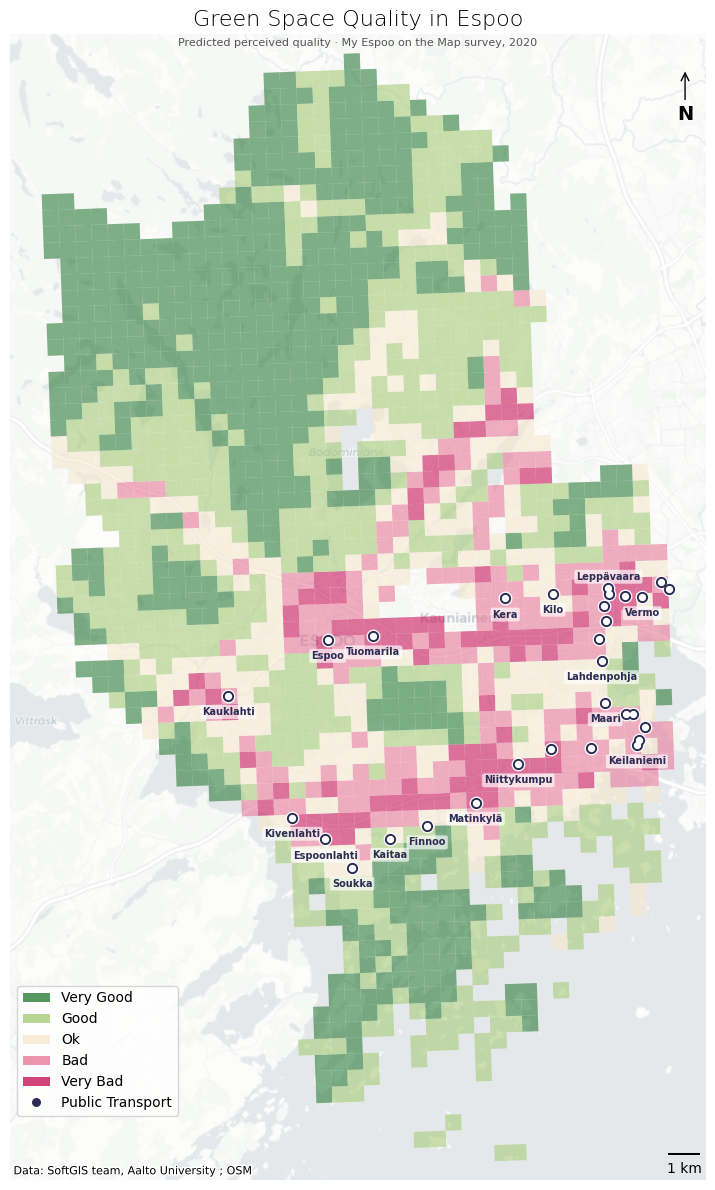

In [ ]:

# Second verion
# Custom colormap: red (bad) → yellow (ok) → green (good)
colors = ["#c9165b", "#e8799a", "#f7e8d0", "#a8cc7a", "#2d7d3a"] # GOOD
# colors = ["#99235c", "#cc88b0", "#f5f5f0", "#6ecfad", "#0d7a5f"] # FINE
cmap_custom = LinearSegmentedColormap.from_list("green_quality", colors)

final_grid = grid_avg.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(8, 12))

final_grid.plot(
    ax=ax,
    column='SCORE',
    cmap=cmap_custom,
    scheme="NaturalBreaks",
    k=5,
    linewidth=0,
    alpha=0.6,
    legend=False,          
)

# --- Custom legend ---
legend_labels = ["Very Good", "Good", "Ok", "Bad", "Very Bad"]
legend_colors = colors[::-1]

legend_handles = [
    Patch(facecolor=color, label=label, alpha=0.8)
    for color, label in zip(legend_colors, legend_labels)
]

# Fetch all stations
stations = ox.features_from_place("Espoo, Finland", tags={"railway": "station"})
stations = stations[stations.geometry.type == "Point"].to_crs("EPSG:3857")

# Outer circle (white halo for contrast over any bg)
stations.plot(ax=ax, color="white", markersize=80, zorder=6)
# Filled circle
stations.plot(ax=ax, color="#2c2c54", markersize=50, zorder=7)
# Inner dot
stations.plot(ax=ax, color="white", markersize=18, zorder=8)

station_handle = Line2D([0], [0], marker="o", color="w", 
                         markerfacecolor="#2c2c54", markersize=8,
                         markeredgecolor="white", markeredgewidth=1.5,
                         label="Public Transport")


# Stations you always want labelled regardless
priority = [ "Soukka", "Kaitaa", "Finnoo", "Kivenlahti", "Espoonlahti", "Kauklahti", "Matinkylä", "Keilaniemi", "Espoo", "Tuomarila", "Kera", "Kilo", "Lahdenpohja", "Niittykumpu", "Maari", "Vermo"]
placed = []

for _, row in stations.iterrows():
    name = row.get("name", "")
    if not name:
        continue
    
    x, y = row.geometry.x, row.geometry.y
    
    # Always label priority stations
    if name == "Leppävaara":
        ax.annotate(
            name,
            xy=(x, y),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=7,
            color="#2c2c54",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.65, ec="none")
        )
    if name in priority and name not in placed:
        ax.annotate(
            name,
            xy=(x, y),
            xytext=(0, -8),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=7,
            color="#2c2c54",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.65, ec="none")
        )
        placed.append(name)
    # Always plot the dot, just skip the label

all_handles = legend_handles + [station_handle]

ax.legend(
    handles=all_handles,
    loc="lower left",
    bbox_to_anchor = (0, 0.05),
    framealpha=0.8,
    fontsize=10,
)

ax.set_axis_off()
# ax.set_title('Green Space Quality in Espoo\n', fontsize=16)

x1, x2 = ax.get_xlim()
y1, y2 = ax.get_ylim()

# Trim — adjust the fractions to taste
vertical_trim = (y2 - y1) * 0.03  # cut 3% off each end
ax.set_ylim(y1 + vertical_trim, y2 - vertical_trim)

plt.title('Green Space Quality in Espoo', fontdict={'fontsize': '16', 'fontweight': '3'})
ax.text(0.5, 0.99, 'Predicted perceived quality · My Espoo on the Map survey, 2020', transform=ax.transAxes, ha='center', fontsize=8, color='#555')

contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Positron,
    alpha=0.6,
    attribution="Data: SoftGIS team, Aalto University ; OSM"
)

latitude = 60.2
scalebar = sb.ScaleBar(
    np.cos(np.radians(latitude)), units='m',
    fixed_value=1, width_fraction=0.002, fixed_units="km",
    location='lower right', scale_loc='bottom',
    box_alpha=0, color='black'
)
ax.add_artist(scalebar)

ax.annotate('N', xy=(0.97, 0.97), xycoords='axes fraction',
            ha='center', va='center', fontsize=14, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            xytext=(0.97, 0.93))

plt.tight_layout()
plt.savefig(MAP_DIRECTORY / "map3.png", dpi=300, bbox_inches="tight")
plt.show()